In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Project root:", os.getcwd())

Project root: C:\Users\user\Desktop\Plant_Stress_Domain_Shift


In [2]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from PIL import Image

from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = MobileNet_V3_Small_Weights.DEFAULT
model = mobilenet_v3_small(weights=weights)

model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)

model_path = "models/mobilenetv3_small_plantvillage_20000.pth"
model.load_state_dict(torch.load(model_path, map_location=device))

model = model.to(device)
model.eval()

print("Device:", device)
print("MobileNetV3-Small 20,000 model loaded.")

Device: cpu
MobileNetV3-Small 20,000 model loaded.


In [3]:
image_size = 224

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class PlantStressDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "image_path"]
        label = int(self.dataframe.loc[index, "label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

print("Transform and Dataset class ready.")

Transform and Dataset class ready.


In [4]:
label_map = {
    "Healthy": 0,
    "Stressed/Diseased": 1
}

# PlantVillage validation
plantvillage_df = pd.read_csv("data/PlantVillage/plantvillage_binary_metadata.csv")
plantvillage_df["label"] = plantvillage_df["binary_label"].map(label_map)

df_healthy = plantvillage_df[plantvillage_df["label"] == 0].sample(n=10000, random_state=42)
df_stressed = plantvillage_df[plantvillage_df["label"] == 1].sample(n=10000, random_state=42)

df_large_sample = pd.concat([df_healthy, df_stressed]).reset_index(drop=True)

_, plantvillage_val_df = train_test_split(
    df_large_sample,
    test_size=0.2,
    random_state=42,
    stratify=df_large_sample["label"]
)

# PlantDoc
plantdoc_df = pd.read_csv("data/PlantDoc/plantdoc_binary_metadata.csv")
plantdoc_df["label"] = plantdoc_df["binary_label"].map(label_map)

# Plant Pathology 2020
pp2020_df = pd.read_csv("data/PlantPathology2020/plantpathology2020_binary_metadata.csv")
pp2020_df["label"] = pp2020_df["binary_label"].map(label_map)

print("PlantVillage validation:", len(plantvillage_val_df))
print("PlantDoc:", len(plantdoc_df))
print("Plant Pathology 2020:", len(pp2020_df))

PlantVillage validation: 4000
PlantDoc: 2572
Plant Pathology 2020: 1821


In [5]:
def get_probabilities(dataframe, batch_size=16):
    dataset = PlantStressDataset(
        dataframe,
        transform=val_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    all_labels = []
    all_probabilities = []

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)

            all_labels.extend(labels.numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())

    return np.array(all_labels), np.array(all_probabilities)


print("Probability function ready.")

Probability function ready.


In [6]:
pv_labels, pv_probabilities = get_probabilities(plantvillage_val_df)
plantdoc_labels, plantdoc_probabilities = get_probabilities(plantdoc_df)
pp2020_labels, pp2020_probabilities = get_probabilities(pp2020_df)

print("Probabilities ready.")
print("PlantVillage validation:", len(pv_labels))
print("PlantDoc:", len(plantdoc_labels))
print("Plant Pathology 2020:", len(pp2020_labels))

print("\nFirst 5 PlantVillage probabilities:", pv_probabilities[:5])
print("First 5 PlantDoc probabilities:", plantdoc_probabilities[:5])
print("First 5 Plant Pathology 2020 probabilities:", pp2020_probabilities[:5])

Probabilities ready.
PlantVillage validation: 4000
PlantDoc: 2572
Plant Pathology 2020: 1821

First 5 PlantVillage probabilities: [0.97036976 0.00987747 0.0041249  0.99303293 0.45463967]
First 5 PlantDoc probabilities: [0.99998903 1.         0.99942565 0.9999751  0.9999964 ]
First 5 Plant Pathology 2020 probabilities: [0.99977964 1.         0.9544777  0.99739647 0.96074075]


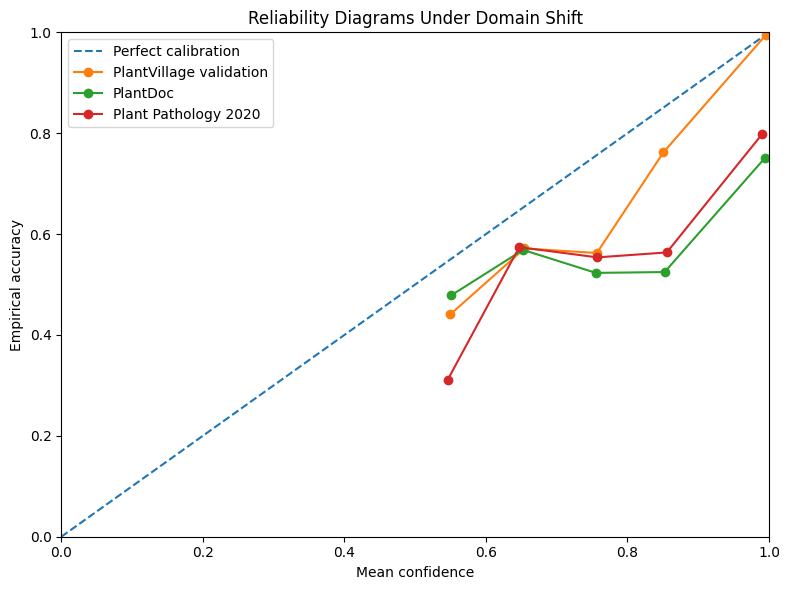

Saved: results/reliability_diagrams_mobilenetv3_20000.png
Saved: paper_outputs/figures/Figure_8_reliability_diagrams.png


In [7]:
def reliability_bins(labels, probabilities, n_bins=10):
    labels = np.array(labels)
    probabilities = np.array(probabilities)

    predictions = (probabilities >= 0.5).astype(int)
    confidences = np.where(predictions == 1, probabilities, 1 - probabilities)
    correctness = (predictions == labels).astype(int)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_accuracy = []
    bin_confidence = []
    bin_counts = []

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        in_bin = (confidences > lower) & (confidences <= upper)

        if np.sum(in_bin) > 0:
            bin_centers.append((lower + upper) / 2)
            bin_accuracy.append(np.mean(correctness[in_bin]))
            bin_confidence.append(np.mean(confidences[in_bin]))
            bin_counts.append(np.sum(in_bin))

    return np.array(bin_centers), np.array(bin_accuracy), np.array(bin_confidence), np.array(bin_counts)


datasets = [
    ("PlantVillage validation", pv_labels, pv_probabilities),
    ("PlantDoc", plantdoc_labels, plantdoc_probabilities),
    ("Plant Pathology 2020", pp2020_labels, pp2020_probabilities)
]

plt.figure(figsize=(8, 6))

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

for dataset_name, labels, probabilities in datasets:
    bin_centers, bin_accuracy, bin_confidence, bin_counts = reliability_bins(
        labels,
        probabilities,
        n_bins=10
    )

    plt.plot(
        bin_confidence,
        bin_accuracy,
        marker="o",
        label=dataset_name
    )

plt.title("Reliability Diagrams Under Domain Shift")
plt.xlabel("Mean confidence")
plt.ylabel("Empirical accuracy")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

figure_path = "results/reliability_diagrams_mobilenetv3_20000.png"
plt.savefig(figure_path, dpi=300)

paper_figure_path = "paper_outputs/figures/Figure_8_reliability_diagrams.png"
plt.savefig(paper_figure_path, dpi=300)

plt.show()

print("Saved:", figure_path)
print("Saved:", paper_figure_path)

In [8]:
Prochaine étape Q1

Maintenant on ajoute une section courte dans l’article pour expliquer la baseline ResNet18 dans la discussion.

Dans ton document Word, dans la section 5. Discussion, ajoute ce sous-titre après 5.2 Effect of Training Data Size :

5.3 Effect of Model Architecture

Puis ajoute ce paragraphe :

The comparison between MobileNetV3-Small and ResNet18 shows that domain shift affects more than one architecture. MobileNetV3-Small achieved higher F1-scores across the evaluated datasets, especially on Plant Pathology 2020, where it obtained an F1-score of 0.8488 compared with 0.7343 for ResNet18. However, ResNet18 achieved higher ROC-AUC values on the external datasets, suggesting that it may provide better probability ranking even when its default-threshold classification performance is weaker. This highlights the importance of evaluating multiple metrics rather than relying on a single performance indicator.

SyntaxError: invalid character '’' (U+2019) (2788474024.py, line 3)

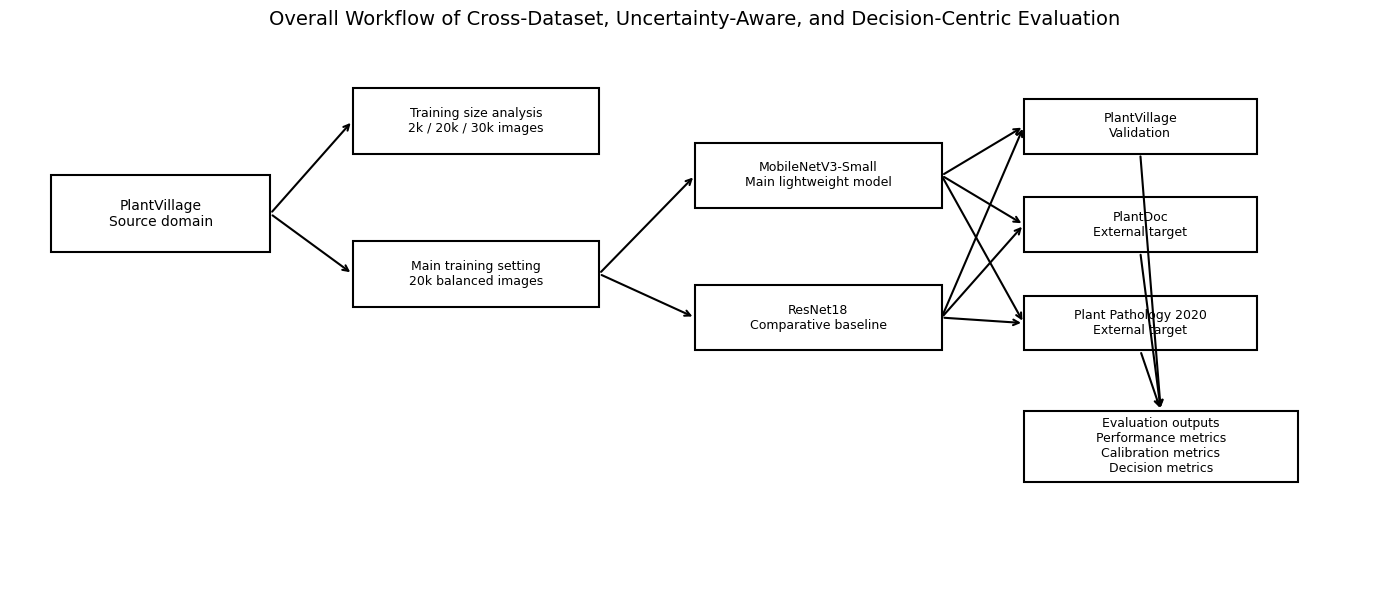

Saved: paper_outputs/figures/Figure_1_workflow_updated.png


In [9]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

os.makedirs("paper_outputs/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

def add_box(x, y, w, h, text, fontsize=9):
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=1.5))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)

def add_arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

add_box(0.03, 0.60, 0.16, 0.14, "PlantVillage\nSource domain", 10)

add_box(0.25, 0.78, 0.18, 0.12, "Training size analysis\n2k / 20k / 30k images", 9)
add_box(0.25, 0.50, 0.18, 0.12, "Main training setting\n20k balanced images", 9)

add_box(0.50, 0.68, 0.18, 0.12, "MobileNetV3-Small\nMain lightweight model", 9)
add_box(0.50, 0.42, 0.18, 0.12, "ResNet18\nComparative baseline", 9)

add_box(0.74, 0.78, 0.17, 0.10, "PlantVillage\nValidation", 9)
add_box(0.74, 0.60, 0.17, 0.10, "PlantDoc\nExternal target", 9)
add_box(0.74, 0.42, 0.17, 0.10, "Plant Pathology 2020\nExternal target", 9)

add_box(0.74, 0.18, 0.20, 0.13, "Evaluation outputs\nPerformance metrics\nCalibration metrics\nDecision metrics", 9)

add_arrow(0.19, 0.67, 0.25, 0.84)
add_arrow(0.19, 0.67, 0.25, 0.56)

add_arrow(0.43, 0.56, 0.50, 0.74)
add_arrow(0.43, 0.56, 0.50, 0.48)

add_arrow(0.68, 0.74, 0.74, 0.83)
add_arrow(0.68, 0.74, 0.74, 0.65)
add_arrow(0.68, 0.74, 0.74, 0.47)

add_arrow(0.68, 0.48, 0.74, 0.83)
add_arrow(0.68, 0.48, 0.74, 0.65)
add_arrow(0.68, 0.48, 0.74, 0.47)

add_arrow(0.825, 0.78, 0.84, 0.31)
add_arrow(0.825, 0.60, 0.84, 0.31)
add_arrow(0.825, 0.42, 0.84, 0.31)

plt.title(
    "Overall Workflow of Cross-Dataset, Uncertainty-Aware, and Decision-Centric Evaluation",
    fontsize=14
)

plt.tight_layout()

figure_path = "paper_outputs/figures/Figure_1_workflow_updated.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved:", figure_path)